In [1]:
from main import *
from Utils.plotting_functions import *
from Worlds.World import World
import Drone.Simulation
from matplotlib import pyplot as plt
from Optimizations.GWO_optimizer import GWOOptimizer

parameters = load_parameters("Settings/simulation_parameters.yaml")

A = parameters['start_point']
B = parameters['end_point']

init_state = create_initial_state(A[0], A[1], A[2])

thrust_max = get_max_thrust_from_rotor_model(parameters)
pid_gains = load_pid_gains(parameters)
quad_controller = create_quadcopter_controller(init_state, pid_gains, thrust_max, parameters)
drone = create_quadcopter_model(init_state, quad_controller, parameters)
world = World.load_world(parameters['world_data_path'])
noise_model = load_dnn_noise_model(parameters)

In [3]:
sim = Simulation(
    drone,
    world,
    waypoints=[], 
    dt=float(parameters['dt']),
    max_simulation_time=float(parameters['simulation_time']),
    frame_skip=int(parameters['frame_skip']),
    target_reached_threshold=float(parameters['threshold']),
    target_shift_threshold_distance=float(parameters['target_shift_threshold_distance']),
    noise_model=noise_model,
    generate_sound_emission_map=False,
    compute_psychoacoustics=False,
    noise_annoyance_radius=9,
)

optimizer = GWOOptimizer(
    simulation_object = sim,
    config_file = None,
    A = parameters['start_point'],
    B = parameters['end_point'],
)


[ GWO ]> No configuration file provided, using default settings.


[ GWO ]> Gen 1/100, Best Cost: 667.22, History Best: 667.22
[ GWO ]> Gen 2/100, Best Cost: 545.20, History Best: 545.20
[ GWO ]> Gen 3/100, Best Cost: 538.61, History Best: 538.61
[ GWO ]> Gen 4/100, Best Cost: 502.16, History Best: 502.16
[ GWO ]> Gen 5/100, Best Cost: 452.60, History Best: 452.60
[ GWO ]> Gen 6/100, Best Cost: 452.60, History Best: 452.60
[ GWO ]> Gen 7/100, Best Cost: 421.74, History Best: 421.74
[ GWO ]> Gen 8/100, Best Cost: 401.68, History Best: 401.68
[ GWO ]> Gen 9/100, Best Cost: 391.30, History Best: 391.30
[ GWO ]> Gen 10/100, Best Cost: 389.64, History Best: 389.64
[ GWO ]> Gen 11/100, Best Cost: 389.64, History Best: 389.64
[ GWO ]> Gen 12/100, Best Cost: 389.64, History Best: 389.64
[ GWO ]> Gen 13/100, Best Cost: 379.41, History Best: 379.41
[ GWO ]> Gen 14/100, Best Cost: 379.41, History Best: 379.41
[ GWO ]> Gen 15/100, Best Cost: 372.21, History Best: 372.21
[ GWO ]> Gen 16/100, Best Cost: 372.21, History Best: 372.21
[ GWO ]> Gen 17/100, Best Cost: 3

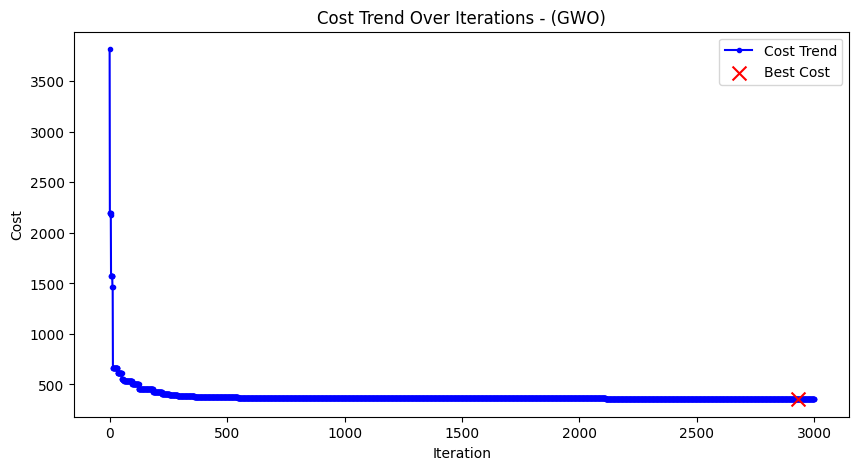

In [4]:
optimizer.start_optimization()